# 5 - Multi Agent Reinforcement Learning

## Problem Definition

A smart city requires coordinated traffic signal control across multiple intersections

In [1]:
from mpe2 import simple_spread_v3, simple_tag_v3
import numpy as np
import matplotlib.pyplot as plt

Running Cooperative Navigation (Simple Spread)...


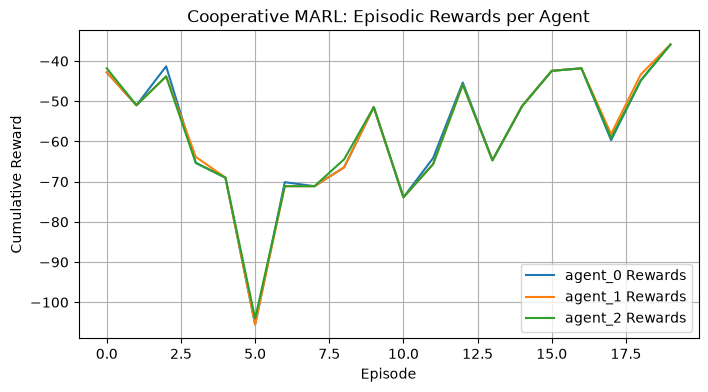

In [ ]:
def simulate_cooperative_marl(episodes=5):
    """
    Simulates Cooperative Navigation where agents share a global goal.
    Agents must navigate to cover all landmarks while avoiding collisions.
    """
    # Initialize environment with 3 agents and 3 landmarks
    env = simple_spread_v3.env(N=3, local_ratio=0.5, max_cycles=50)

    agent_rewards = {agent: [] for agent in env.possible_agents}

    for ep in range(episodes):
        env.reset()
        ep_rewards = {agent: 0.0 for agent in env.possible_agents}

        # PettingZoo's standard Agent-Environment-Cycle (AEC) loop
        for agent in env.agent_iter():
            observation, reward, termination, truncation, info = env.last()

            if termination or truncation:
                action = None
            else:
                # Using a random policy for simulation
                action = env.action_space(agent).sample()

            env.step(action)
            ep_rewards[agent] += float(reward)

        for agent in env.possible_agents:
            agent_rewards[agent].append(ep_rewards[agent])

    env.close()
    return agent_rewards


# Run simulation
print("Running Cooperative Navigation (Simple Spread)...")
coop_rewards = simulate_cooperative_marl(episodes=20)

# Visualize reward sharing
plt.figure(figsize=(8, 4))
for agent, rewards in coop_rewards.items():
    plt.plot(rewards, label=f"{agent} Rewards")
plt.title("Cooperative MARL: Episodic Rewards per Agent")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.grid(True)
plt.show()

Running Predator-Prey Simulation (Simple Tag)...


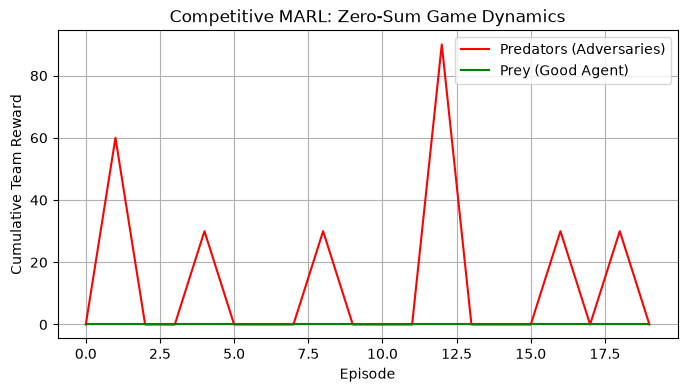

In [ ]:
def simulate_competitive_marl(episodes=5):
    """
    Simulates Predator-Prey (Competitive).
    Good agents (prey) are rewarded for evading.
    Adversary agents (predators) are rewarded for catching the prey.
    """
    # 3 predators (adversaries), 1 prey (good agent)
    env = simple_tag_v3.env(
        num_good=1, num_adversaries=3, num_obstacles=2, max_cycles=50
    )

    team_rewards = {"predators": [], "prey": []}

    for ep in range(episodes):
        env.reset()
        ep_rewards = {agent: 0.0 for agent in env.possible_agents}

        for agent in env.agent_iter():
            observation, reward, termination, truncation, info = env.last()

            if termination or truncation:
                action = None
            else:
                action = env.action_space(agent).sample()

            env.step(action)
            ep_rewards[agent] += float(reward)

        # Aggregate rewards by team
        predator_reward = sum(
            ep_rewards[agent] for agent in env.possible_agents if "adversary" in agent
        )
        prey_reward = sum(
            ep_rewards[agent] for agent in env.possible_agents if "good" in agent
        )

        team_rewards["predators"].append(predator_reward)
        team_rewards["prey"].append(prey_reward)

    env.close()
    return team_rewards


print("Running Predator-Prey Simulation (Simple Tag)...")
comp_rewards = simulate_competitive_marl(episodes=20)

# Visualize Competitive Dynamics
plt.figure(figsize=(8, 4))
plt.plot(comp_rewards["predators"], label="Predators (Adversaries)", color="red")
plt.plot(comp_rewards["prey"], label="Prey (Good Agent)", color="green")
plt.title("Competitive MARL: Zero-Sum Game Dynamics")
plt.xlabel("Episode")
plt.ylabel("Cumulative Team Reward")
plt.legend()
plt.grid(True)
plt.show()

## Key Questions

### 1. What is Multi-Agent Reinforcement Learning (MARL)?
MARL is an extension of standard reinforcement learning where multiple autonomous agents inhabit a shared environment simultaneously. Instead of a single agent optimizing its policy against a static environment, multiple agents must learn to interact, negotiate, and optimize their policies while accounting for the actions and learning processes of other agents.

### 2. How do agents cooperate or compete?
* **Cooperation:** Agents collaborate to achieve a shared, global objective (e.g., autonomous vehicles coordinating traffic signal control to minimize city-wide congestion). They typically share a common reward signal, meaning if the team succeeds, all agents are rewarded equally.
* **Competition:** Agents have mutually exclusive goals, often modeled as zero-sum games (e.g., predator-prey simulations). One agent's positive reward directly results in a negative reward (penalty) for the opposing agent. 

### 3. What challenges arise due to non-stationarity?
In single-agent RL, the environment's transition dynamics are stationary (consistent). In MARL, because all agents are simultaneously updating their policies, the "environment" (from the perspective of any single agent) is constantly changing. This violates the Markov property, making it extremely difficult for traditional algorithms like Q-learning to converge, as an action that was optimal yesterday might be heavily penalized today due to a shift in another agent's strategy.

### 4. How are rewards shared among agents?
Rewards in MARL can be structured in a spectrum from local to global:
* **Global Rewards:** All agents receive the exact same reward based on the overall team performance. This strongly encourages cooperation but introduces the **Credit Assignment Problem**—it is difficult for an individual agent to determine how its specific action contributed to the team's success or failure.
* **Local Rewards:** Each agent receives a reward strictly based on its individual performance. This solves the credit assignment problem but often leads to greedy, selfish behavior that degrades the overall system's efficiency (e.g., a single car rushing a traffic light, causing a gridlock).
* **Mixed/Shaped Rewards (e.g., `local_ratio` in PettingZoo):** A weighted combination of individual performance and team success, balancing personal accountability with cooperative behavior.

---

## Supplementary Problems Addressed
* **Cooperative Navigation:** Modeled using PettingZoo's `simple_spread_v3` environment, demonstrating shared global objectives.
* **Predator-Prey Simulation:** Modeled using PettingZoo's `simple_tag_v3` environment, demonstrating competitive zero-sum adversarial dynamics.